# Lab 10 — Cancer as loss of module identifiability

*Tenth and final session of the [`notebooks/` course](README.md) — a **stretch lab**: the metrics
this course built, turned diagnostic.*

The course built an instrument that, given a regulome, tells you how *fidelitous* it is ([Lab 3](03_benchmarking_fidelity.ipynb)),
how *modular* it is ([Lab 4](04_modularity_identifiability.ipynb)), which of its dynamics are *stable
drivers* vs *transient stress* ([Lab 5](05_hypergraph_neural_odes.ipynb)), how *steerable* it is
([Labs 6–8](06_control_theory.ipynb)). This lab points all of that at a disease.

Cancer has two big framings. The dominant **somatic-mutation theory (SMT)** — accumulating mutations
in oncogenes/tumour-suppressors hijack a cell. The minority **tissue-organisation field theory (TOFT)**
(Soto & Sonnenschein) — cancer is a *tissue-level, organisational* disorder, a breakdown of the
constraints that keep cells cooperating in a body plan. They are not mutually exclusive, and this lab
sits squarely in the second register, joined by two adjacent ideas: Trigos *et al.*'s **atavism**
(tumours over-express deeply conserved *unicellular-ancestral* genes — multicellularity coming
undone), and Levin's **bioelectric** view (depolarisation as an oncogenic signal; "cancer is a
disorder of the cellular collective's morphogenetic goals"). And it has a precise echo of Davidson
([Lab 2](02_regulomes_and_hypergraphs.ipynb)): a tumour is, partly, a body-part-defining GRN *kernel*
coming loose, or a *differentiation gene battery* that fails to deploy.

The hypothesis this lab makes operational: **cancer ⇒ the regulome's modular structure dissolves ⇒
the Module Identifiability Index falls**; and, dynamically ([Lab 5](05_hypergraph_neural_odes.ipynb)),
the *homeostatic driver set* loses authority while *transient / wound / proliferative* programs become
**persistent** — i.e. cancer is, in flow terms, **the reverse of regeneration** (the kidney-injury
split of Lab 5 run backwards: the stable drivers destabilise, the transient responders never switch
off — "tumours are wounds that do not heal", Dvorak).

> **Honest caveat up front.** The matched **primary → organoid → tumour-organoid → cancer-line** Hodge-
> spectrum series the hypothesis really wants is **not in this repo**. So the gradient here is partly
> *predicted*: we anchor on the one real cross-system comparison we have (Lab 4's self-organised /
> blueprint / constructed trio — and even there the differences are small, the metric is a coarse
> proxy), illustrate the *kind* of spectral change cancer would produce with a clearly-labelled
> synthetic "dedifferentiation" knob, and make "run the real gradient" the headline exercise (5a).
> Loss-of-module-identifiability is *one facet* of cancer (the organisational/atavistic one) — it sits
> *alongside* the mutational view, not instead of it.

**Needs:** `numpy`, `scipy`, `matplotlib`. Reads `figures/{kidney_modularity_results,nitmb_modularity_report,
regenerative_flow_results}.json`; synthetic fallbacks so every cell runs. **Refs:** Soto & Sonnenschein
(TOFT); Trigos *et al.* (atavism); Levin 2021 (Cell — bioelectric circuits in cancer); Hanahan &
Weinberg (hallmarks); Davidson; Hartwell 1999; Pio-Lopez & Levin 2023 (morphoceuticals). Pipeline:
`scripts/{benchmark_kidney_modularity,test_nitmb_modularity,benchmark_disease_enrichment,benchmark_tf_disease,
benchmark_tang_bioprinting,validate_choose}.py`.

In [1]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(0)

def _find(*parts):
    here = Path.cwd()
    for base in [here, *here.parents]:
        p = base.joinpath(*parts)
        if p.exists():
            return p
    return None
def _loadjson(*parts):
    p = _find(*parts);  return json.loads(p.read_text()) if p else None

# ---- the Lab-4 Module-Identifiability machinery (verbatim) -----------------------------------
def mii_heuristic(spectrum, n=10):
    """The project's Module Identifiability Index (scripts/test_nitmb_modularity.py):
    mean of the first n spectral gaps / std of the first n eigenvalues. A coarse, monotone proxy
    (Lab 4) — it discriminates *between* systems of the same scale, it doesn't pull a module count
    out of a tangled GRN."""
    s = np.sort(np.asarray(spectrum, float))
    if len(s) < 2:
        return 0.0
    gaps = np.diff(s)
    return float(np.mean(gaps[:n]) / (np.std(s[:n]) + 1e-8))

def relative_eigengap(spectrum, k_max=12, null_thr_frac=0.02):
    """A normalised eigengap ∈[0,1]: drop the near-zero harmonic block (eigenvalues below
    null_thr_frac · max), then g_k = (λ_{k+1}-λ_k)/λ_{k+1} over k≤k_max — return (k_star, g_star).
    Big g_star ⇒ a clean 'plateau then cliff' ⇒ a few well-separated modules; small ⇒ diffuse."""
    s = np.sort(np.asarray(spectrum, float))
    thr = null_thr_frac * (s.max() + 1e-12)
    n_null = int((s < thr).sum())
    s = s[s >= thr][: k_max + 1]
    if len(s) < 2:
        return n_null + 1, 0.0
    g = (s[1:] - s[:-1]) / np.maximum(s[1:], 1e-12)
    k = int(np.argmax(g))
    return n_null + k + 1, float(g[k])

def fiedler(spectrum):
    s = np.sort(np.asarray(spectrum, float))
    nz = s[s > 1e-6]
    return float(nz[0]) if len(nz) else 0.0

kidney_hodge = _loadjson("figures", "kidney_modularity_results.json")    # {kidney|brain|kidney_ref: {ev0,ev1,fiedler,...}}
nitmb_report = _loadjson("figures", "nitmb_modularity_report.json")       # [{system, identifiability_score}, ...]
regen_flow   = _loadjson("figures", "regenerative_flow_results.json")     # kidney-IRI per-TF rollout MSE

print("loaded:", {k: bool(v) for k, v in dict(kidney_modularity=kidney_hodge, nitmb_report=nitmb_report,
                                               regenerative_flow=regen_flow).items()})
print("Lab-4 machinery ready: mii_heuristic, relative_eigengap, fiedler.")

loaded: {'kidney_modularity': True, 'nitmb_report': True, 'regenerative_flow': True}
Lab-4 machinery ready: mii_heuristic, relative_eigengap, fiedler.


## 1. The prediction — what dedifferentiation does to the Hodge spectrum

Before going to the data, *predict* what the lens should show. A well-modularised regulome has a
**plateau-then-cliff** low-lying spectrum: a few small eigenvalues (one per module's worth of slow
modes), a flat-ish run, then a *jump* to the densely-packed bulk. A diffuse one has a **smooth
ramp** — no plateau, no cliff, no dominant scale. So dedifferentiation ≈ *the plateau and cliff
melt into the ramp*, and **the relative eigengap $\in [0,1]$ (Lab 4's normalised gap measure) should
walk left** as you traverse a primary → organoid → tumour-organoid → cancer-line gradient.

Below are **three hand-drawn schematic spectra** — *not data*, deliberately: a "differentiated /
in-vivo blueprint" (a clear plateau-then-cliff), an "organoid" (a softer, blurred version), and a
"tumour / cancer line" (a smooth ramp). The `relative_eigengap` tracks the cartoon and ranks them
in the predicted order; the coarse `mii_heuristic` does *not* — Lab 4's caveat in action. **This is
the shape §2 then looks for in real data — and finds only a narrow shadow of, because we don't yet
have a matched cancer gradient.**


                  schematic spectrum    rel. eigengap (k*)   MII (heuristic)    Fiedler λ₂
  differentiated / in-vivo blueprint           0.860 (k*= 5)             0.239     1.000e-04
           organoid (self-organised)           0.400 (k*= 5)             0.292     1.000e-04
                tumour / cancer line           0.341 (k*= 2)             0.361     1.000e-04


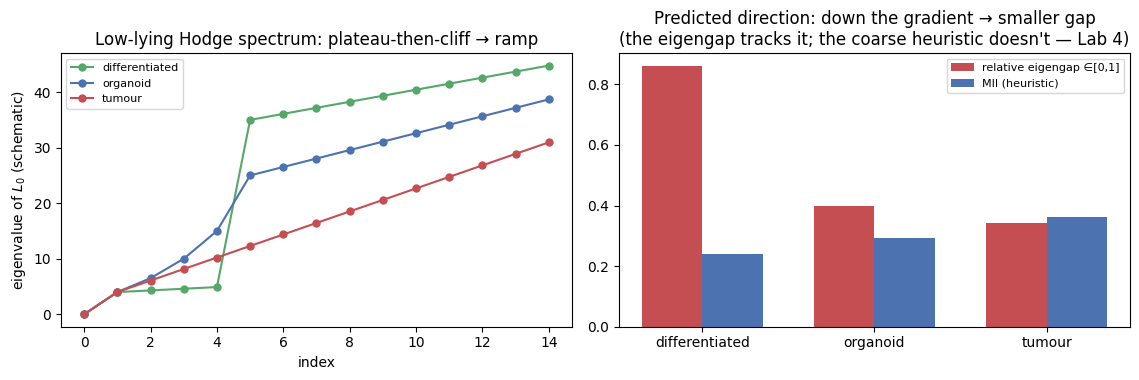

  ↳ a primary → organoid → tumour-organoid → cancer-line series should walk *left* on the eigengap bar — exercise (5a) tests whether real data does.


In [2]:
# three SCHEMATIC L0 spectra (hand-drawn — not data): clear cliff → soft cliff → no cliff
def _spec(plateau, bulk_lo, bulk_n=24, bulk_hi=60.0):
    return np.concatenate([[1e-4], np.asarray(plateau, float), np.linspace(bulk_lo, bulk_hi, bulk_n)])
cartoons = {
    "differentiated / in-vivo blueprint": _spec([4.0, 4.3, 4.6, 4.9], bulk_lo=35.0),   # sharp plateau, big cliff (4.9 → 35)
    "organoid (self-organised)":            _spec([4.0, 6.5, 10.0, 15.0], bulk_lo=25.0), # blurred plateau, softer cliff
    "tumour / cancer line":                 np.concatenate([[1e-4], np.linspace(4.0, 60.0, 28)]),  # smooth ramp — no plateau, no cliff
}
print(f"{'schematic spectrum':>36}  {'rel. eigengap (k*)':>20}  {'MII (heuristic)':>16}  {'Fiedler λ₂':>12}")
for name, ev in cartoons.items():
    ks, gs = relative_eigengap(ev)
    print(f"{name:>36}  {gs:>14.3f} (k*={ks:>2d})  {mii_heuristic(ev):>16.3f}  {fiedler(ev):>12.3e}")
fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.9))
cols = ["#55A868", "#4C72B0", "#C44E52"]
for (name, ev), c in zip(cartoons.items(), cols):
    ax[0].plot(range(min(15, len(ev))), ev[:15], "o-", ms=5, color=c, label=name.split(" (")[0].split(" / ")[0])
ax[0].set_xlabel("index"); ax[0].set_ylabel("eigenvalue of $L_0$ (schematic)"); ax[0].set_title("Low-lying Hodge spectrum: plateau-then-cliff → ramp"); ax[0].legend(fontsize=8)
gs_vals = [relative_eigengap(ev)[1] for ev in cartoons.values()]
mii_vals = [mii_heuristic(ev) for ev in cartoons.values()]
x = np.arange(3); w = 0.35
ax[1].bar(x - w/2, gs_vals, w, color="#C44E52", label="relative eigengap ∈[0,1]")
ax[1].bar(x + w/2, mii_vals, w, color="#4C72B0", label="MII (heuristic)")
ax[1].set_xticks(x); ax[1].set_xticklabels(["differentiated", "organoid", "tumour"]); ax[1].legend(fontsize=8)
ax[1].set_title("Predicted direction: down the gradient → smaller gap\n(the eigengap tracks it; the coarse heuristic doesn't — Lab 4)")
fig.tight_layout(); plt.show()
print("  ↳ a primary → organoid → tumour-organoid → cancer-line series should walk *left* on the eigengap bar — exercise (5a) tests whether real data does.")

## 2. The real data — a narrow shadow of the prediction

The matched cancer gradient §1 predicts on isn't in this repo yet (§6(a) — go get it). The one real
**construction** gradient we *do* have, computed the same way (an HVG-correlation hypergraph,
`scripts/benchmark_kidney_modularity.py`), is **brain organoid (self-organised) > fetal kidney (the
*in vivo* blueprint) > bioprinted kidney (constructed cell-by-cell)** — `figures/nitmb_modularity_report.json`.

Note three things and read the bars as confirmation-on-the-predicted-side, not as the headline:
(i) the values sit in a narrow band (~0.35–0.38) — the metric is a *coarse proxy* (Lab 4 was
emphatic); (ii) this is the *scale / self-organisation* axis, not a *cancer* axis; (iii) a cancer
gradient is exactly where you'd predict a *larger* drop — dedifferentiation should degrade the gap
structure much more than "organoid vs blueprint" does. The bars are on the predicted side of zero,
the cartoon in §1 says what we *should* see when the real gradient lands.


                            system   MII (heuristic)   rel. eigengap    Fiedler λ₂
   Brain organoid (self-organised)            0.3812           0.195     7.207e-06
  Fetal kidney (in-vivo blueprint)            0.3667           0.333     6.261e-06
   Bioprinted kidney (constructed)            0.3526           0.172     4.102e-06

  committed nitmb report:  Brain Organoid: 0.3812   Fetal Kidney (Ref): 0.3667   Bioprinted Kidney: 0.3526
  (the MII-heuristic column reproduces it; note the band is narrow — exercise (a): does a *cancer* gradient widen it?)


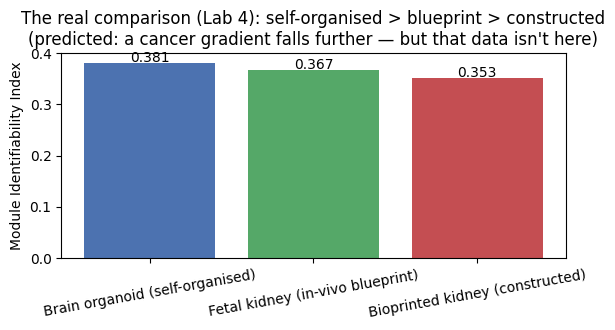

In [3]:
if kidney_hodge:
    system = {"brain": "Brain organoid (self-organised)", "kidney_ref": "Fetal kidney (in-vivo blueprint)",
              "kidney": "Bioprinted kidney (constructed)"}
    rows = []
    for key, label in system.items():
        rec = kidney_hodge.get(key)
        if not rec or not rec.get("ev0"):
            continue
        ev = np.asarray(rec["ev0"], float)
        ks, gs = relative_eigengap(ev)
        rows.append((label, mii_heuristic(ev), gs, float(rec.get("fiedler", fiedler(ev)))))
    rows.sort(key=lambda r: -r[1])
    print(f"{'system':>34}  {'MII (heuristic)':>16}  {'rel. eigengap':>14}  {'Fiedler λ₂':>12}")
    for label, m, g, f in rows:
        print(f"{label:>34}  {m:>16.4f}  {g:>14.3f}  {f:>12.3e}")
    if nitmb_report:
        print("\n  committed nitmb report:  " + "   ".join(f"{d['system']}: {d['identifiability_score']:.4f}"
              for d in sorted(nitmb_report, key=lambda x: -x['identifiability_score'])))
        print("  (the MII-heuristic column reproduces it; note the band is narrow — exercise (a): does a *cancer* gradient widen it?)")
    fig, ax = plt.subplots(figsize=(6.2, 3.4))
    ax.bar([r[0] for r in rows], [r[1] for r in rows], color=["#4C72B0", "#55A868", "#C44E52"][:len(rows)])
    for i, r in enumerate(rows): ax.text(i, r[1] + 0.002, f"{r[1]:.3f}", ha="center")
    ax.set_ylabel("Module Identifiability Index"); ax.set_title("The real comparison (Lab 4): self-organised > blueprint > constructed\n(predicted: a cancer gradient falls further — but that data isn't here)")
    ax.tick_params(axis="x", labelrotation=10); fig.tight_layout(); plt.show()
else:
    print("[note] figures/kidney_modularity_results.json absent — see scripts/benchmark_kidney_modularity.py.")

## 3. The dynamical face — the homeostatic driver set comes loose

[Lab 5](05_hypergraph_neural_odes.ipynb) split a regulome's genes, via the rollout-MSE of a fitted
Hypergraph Neural ODE, into a **homeostatic core** (low MSE — on the slow, identity-defining manifold:
the fate-determining TFs) and a **transient shell** (high MSE — fast, externally-driven spikes: the
immediate-early / wound / stress programs). On the kidney injury–repair plant (`regenerative_flow_results.json`):
*homeostatic* — Lhx1, Cdh1, Pax8, Pax2, Six1/2, Wt1, Foxc2 (MSE ≈ 0.05–0.11); *transient* — Fos (4.4),
Jun (1.5), Cd44 (0.93), Atf3 (0.80).

**Regeneration**: the injury fires the transient programs; once the wound resolves, the *homeostatic*
set re-dominates and the cell returns to its (epithelial, differentiated) attractor — the MSE-mass
flows back to the slow manifold.

**Cancer** = that recovery *fails to terminate*: the proliferative/stress programs become **persistent**
(the "wound that doesn't heal"), the differentiation drivers lose authority, the cell sits in an
off-manifold, partially-dedifferentiated, proliferative state — which is the §1–§2 picture (the modular
structure / the Fiedler-region gap dissolving) seen through the *flow* rather than the spectrum. (And —
Trigos — the persistent programs skew *atavistic*: the deeply conserved unicellular-ancestral stress/
proliferation machinery, freed from the multicellular constraints that normally keep it transient.)

kidney injury–repair: rollout-MSE mass — homeostatic core 0.97 (the slow drivers fit *tightly*)  vs  transient shell 8.00 (dominated by the injury spike — Fos alone 4.4)
  (regeneration: that spike *resolves*; the tightly-fit core program then re-runs the cell to its differentiated attractor.  cancer = the spike never drains.)


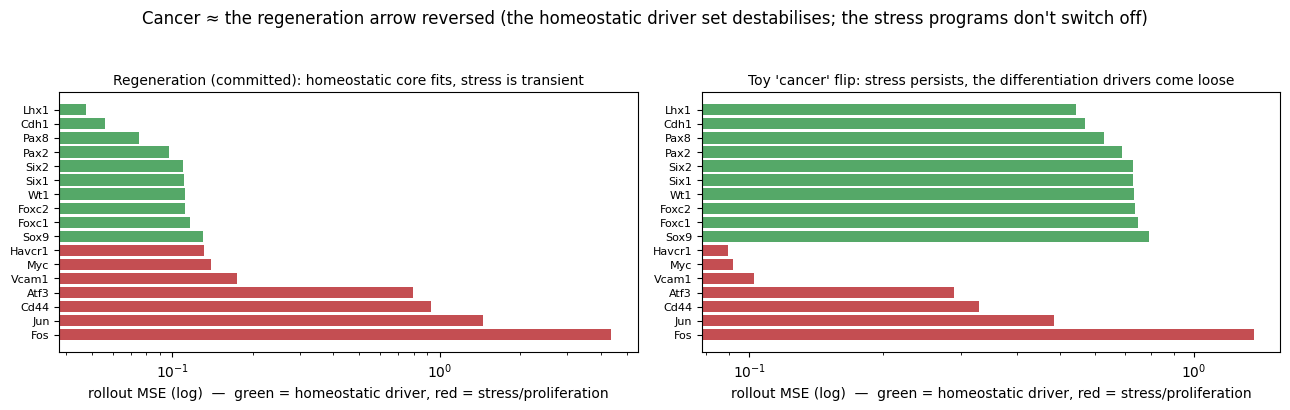

In [4]:
# the regeneration split (committed) — and a toy "cancer" flip
if regen_flow and regen_flow.get("ode", {}).get("per_tf_mse"):
    mse = regen_flow["ode"]["per_tf_mse"]; items = sorted(mse.items(), key=lambda kv: kv[1])
    names = [k for k, _ in items]; vals = np.array([v for _, v in items], float)
    transient = {"Fos", "Jun", "Junb", "Atf3", "Cd44", "Vcam1", "Havcr1", "Myc"}
    is_trans = np.array([n in transient for n in names])
    print(f"kidney injury–repair: rollout-MSE mass — homeostatic core {vals[~is_trans].sum():.2f} (the slow drivers fit *tightly*)  "
          f"vs  transient shell {vals[is_trans].sum():.2f} (dominated by the injury spike — Fos alone {mse.get('Fos', float('nan')):.1f})")
    print(f"  (regeneration: that spike *resolves*; the tightly-fit core program then re-runs the cell to its differentiated attractor.  cancer = the spike never drains.)")
    # toy "cancer" flip: amplify the transient programs' persistence, damp the homeostatic drivers' authority
    cancer_vals = np.where(is_trans, vals * 0.3 + 0.05, vals * 3.0 + 0.4)   # transients become *well-fit/persistent*, drivers become *off-manifold*
    fig, ax = plt.subplots(1, 2, figsize=(13, 3.9))
    for a, v, ttl in [(ax[0], vals, "Regeneration (committed): homeostatic core fits, stress is transient"),
                      (ax[1], cancer_vals, "Toy 'cancer' flip: stress persists, the differentiation drivers come loose")]:
        a.barh(range(len(names)), v[::-1], color=["#C44E52" if t else "#55A868" for t in is_trans[::-1]])
        a.set_yticks(range(len(names))); a.set_yticklabels(names[::-1], fontsize=8); a.set_xscale("log")
        a.set_xlabel("rollout MSE (log)  —  green = homeostatic driver, red = stress/proliferation"); a.set_title(ttl, fontsize=10)
    fig.suptitle("Cancer ≈ the regeneration arrow reversed (the homeostatic driver set destabilises; the stress programs don't switch off)", y=1.04)
    fig.tight_layout(); plt.show()
else:
    print("[note] figures/regenerative_flow_results.json absent — see scripts/benchmark_regenerative_flow.py.")

## 4. The constructive flip — actually steer the tumour basin back

The lens so far is *diagnostic* (the gap fell, the drivers came loose). [Lab 8](08_anatomical_compiler.ipynb)'s
machinery gives it a *constructive* face: **given a low-MII, off-manifold "tumour" basin, solve for
the actuation that returns the cell to the high-MII differentiated basin.** That's the operational
content of *normalise, don't (just) kill* — differentiation therapy / tumour-normalisation rather
than cytotoxicity — with a bioelectric instance (Levin/Mafe: repolarising tumour cells toward a
normal $V_{\rm mem}$ set-point reverts the phenotype; the BETSE-JAX `optimize_pattern` from
[Lab 9 §4](09_synthetic_morphology_wetlab.ipynb)) and a pharmacological one (**morphoceuticals** —
Pio-Lopez & Levin 2023 — drugs that target the *anatomical-control* layer).

Worked here on a **skewed two-attractor toggle**: $x$ = "differentiation TF", $y$ = "proliferation
TF". $\beta_x > \beta_y$ makes the $x$-high (differentiated) basin broader, but a $y$-high (tumour)
basin coexists — a deliberately asymmetric Waddington landscape. Actuator: a non-negative drive on
$x$ (a differentiation-therapy drug). Bisect for the *minimal effective dose* and plot the trajectory
crossing the separatrix — that's the iconic image of "I just steered the cell out of the disease
basin."


  free relaxation:  diff-corner [4.  0.3] → (4.00, 0.04) ✓ stays differentiated
                    tum-corner  [0.3 4. ] → (0.25, 2.46) ✓ stays tumour-like

  bisection → minimal effective dose  u* ≈ 0.087  (drive_x = u_max·tanh(u*) ≈ 0.35)


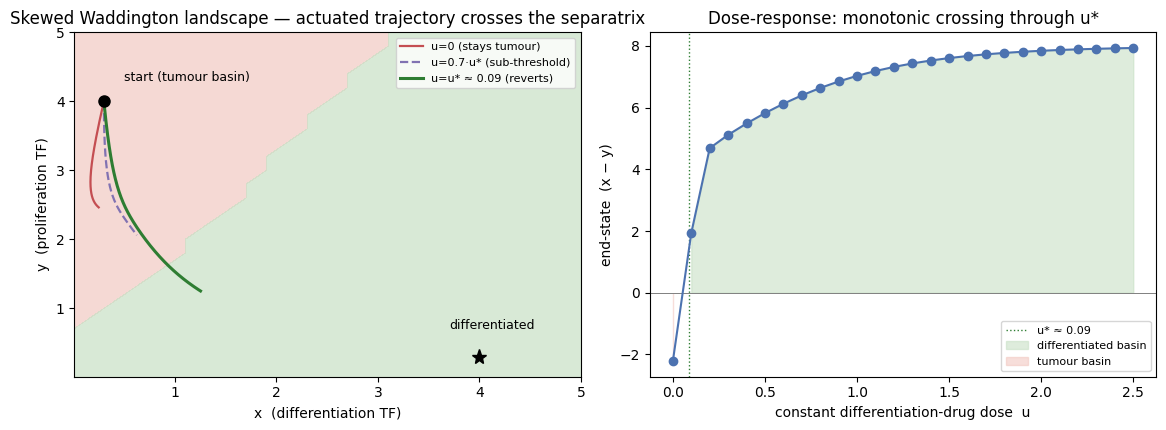

  ↳ §6(d) extends: replace `bisect-on-constant-dose` with Lab 8's gradient-descent on a *schedule* u(t), add a control cost λ‖u‖², and swap in a fitted Hypergraph Neural ODE (Lab 5) or a V_mem actuator (BETSE-JAX).


In [5]:
# §4: the constructive flip — minimal dose to revert a tumour-basin cell to the differentiated basin
# Skewed toggle: x = differentiation TF, y = proliferation TF; β_x > β_y → broader differentiated basin
def skew_toggle(z, bx=4.0, by=2.5, n=3.0):
    x, y = z[..., 0], z[..., 1]
    return np.stack([bx / (1 + y**n) - x, by / (1 + x**n) - y], -1)

def roll_ctrl(z0, u_const, T=8.0, dt=0.04, u_max=4.0, record=False):
    z = np.asarray(z0, float).copy()
    drive_x = u_max * np.tanh(u_const)
    nstep = int(T/dt)
    traj = [z.copy()] if record else None
    for _ in range(nstep):
        z = z + dt*(skew_toggle(z) + np.array([drive_x, 0.0]))
        z = np.maximum(z, 0.0)
        if record: traj.append(z.copy())
    return (z, np.array(traj)) if record else z

# (i) confirm bistability without any drive
z_diff = np.array([4.0, 0.3]); z_tum = np.array([0.3, 4.0])
zf_d = roll_ctrl(z_diff, 0.0); zf_t = roll_ctrl(z_tum, 0.0)
print(f"  free relaxation:  diff-corner {z_diff} → ({zf_d[0]:.2f}, {zf_d[1]:.2f}) ✓ stays differentiated")
print(f"                    tum-corner  {z_tum} → ({zf_t[0]:.2f}, {zf_t[1]:.2f}) ✓ stays tumour-like")

# (ii) bisect for the minimal differentiation-drug dose that flips the tumour cell to the diff basin
def is_reverted(u): zf = roll_ctrl(z_tum, u); return zf[0] > zf[1]
lo, hi = 0.0, 3.0
assert not is_reverted(lo) and is_reverted(hi), "expected lo to fail, hi to succeed"
for _ in range(20):
    mid = 0.5*(lo + hi)
    if is_reverted(mid): hi = mid
    else: lo = mid
u_min = hi
print(f"\n  bisection → minimal effective dose  u* ≈ {u_min:.3f}  (drive_x = u_max·tanh(u*) ≈ {4.0*np.tanh(u_min):.2f})")

# (iii) trajectories: free vs sub-threshold vs at u*
_, traj_free = roll_ctrl(z_tum, 0.0, record=True)
_, traj_sub  = roll_ctrl(z_tum, 0.7*u_min, record=True)
_, traj_min  = roll_ctrl(z_tum, u_min, record=True)

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.4))
# left: basin map (vector field + separatrix proxy via a fine relaxation grid)
xs = np.linspace(0.01, 5.0, 26); ys = np.linspace(0.01, 5.0, 26)
X, Y = np.meshgrid(xs, ys)
basin = np.zeros_like(X)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        zf = roll_ctrl(np.array([X[i,j], Y[i,j]]), 0.0, T=6.0)
        basin[i,j] = 1.0 if zf[0] > zf[1] else 0.0
ax[0].contourf(X, Y, basin, levels=[-0.1, 0.5, 1.1], colors=["#F2C9C2", "#C8E0C5"], alpha=0.7)
ax[0].plot(traj_free[:,0], traj_free[:,1], "-", color="#C44E52", lw=1.6, label=f"u=0 (stays tumour)")
ax[0].plot(traj_sub[:,0],  traj_sub[:,1],  "--", color="#8172B2", lw=1.6, label=f"u=0.7·u* (sub-threshold)")
ax[0].plot(traj_min[:,0],  traj_min[:,1],  "-", color="#2E7D32", lw=2.2, label=f"u=u* ≈ {u_min:.2f} (reverts)")
ax[0].plot(*z_tum, "o", color="black", ms=8); ax[0].annotate("start (tumour basin)", z_tum, xytext=(0.5, 4.3), fontsize=9)
ax[0].plot(4.0, 0.3, "*", color="black", ms=11); ax[0].annotate("differentiated", (4.0, 0.3), xytext=(3.7, 0.7), fontsize=9)
ax[0].set_xlabel("x  (differentiation TF)"); ax[0].set_ylabel("y  (proliferation TF)")
ax[0].set_title("Skewed Waddington landscape — actuated trajectory crosses the separatrix"); ax[0].legend(fontsize=8, loc="upper right")

# right: dose-response — final |x - y| vs constant drive
us = np.linspace(0.0, 2.5, 26)
finals = [roll_ctrl(z_tum, u) for u in us]
diffs = np.array([z[0] - z[1] for z in finals])
ax[1].axhline(0, color="grey", lw=0.7); ax[1].axvline(u_min, color="#2E7D32", lw=1.0, ls=":", label=f"u* ≈ {u_min:.2f}")
ax[1].plot(us, diffs, "o-", color="#4C72B0"); ax[1].fill_between(us, 0, diffs, where=diffs>=0, color="#C8E0C5", alpha=0.6, label="differentiated basin")
ax[1].fill_between(us, 0, diffs, where=diffs<0, color="#F2C9C2", alpha=0.6, label="tumour basin")
ax[1].set_xlabel("constant differentiation-drug dose  u"); ax[1].set_ylabel("end-state  (x − y)")
ax[1].set_title("Dose-response: monotonic crossing through u*"); ax[1].legend(fontsize=8, loc="lower right")
fig.tight_layout(); plt.show()
print("  ↳ §6(d) extends: replace `bisect-on-constant-dose` with Lab 8's gradient-descent on a *schedule* u(t),"
      " add a control cost λ‖u‖², and swap in a fitted Hypergraph Neural ODE (Lab 5) or a V_mem actuator (BETSE-JAX).")


## 5. What this is — and isn't

- **It's a topology/dynamics *proxy*, not a definition of cancer.** Cancer is wildly heterogeneous
  (tissue, driver mutations, stage, microenvironment) — there is no single regulome signature, and the
  module-identifiability lens captures *one facet* (the organisational/atavistic one). It does not
  replace the mutational picture; mutations are, on this view, *one cause* of the modular dissolution.
- **The metric inherits Lab 4's caveats, doubly.** It's a normalised spectral gap (construction-
  dependent, not unique; the coarse `mii_heuristic` is barely sensitive — lead with the `relative_eigengap`
  and the Fiedler value, and report the spectrum); the §1 gradient is a *cartoon*; "module identifiability"
  (this lab, Lab 4) ≠ "structural identifiability of a dynamic model" ([Lab 7](07_structural_identifiability.ipynb))
  ≠ "fidelity" ([Lab 3](03_benchmarking_fidelity.ipynb)) — same words, three different things.
- **The §4 demo is a toggle, not a tumour.** The skewed two-attractor system is the right *cartoon*
  for "normalise, don't kill" — it shows the actuation is a state-space problem with a separatrix to
  cross and a minimal dose. The real-data version (a fitted Hypergraph Neural ODE on a primary/tumour
  timecourse, then Lab 8's machinery on top) is §6(d).
- **The diagnostic flip — "know when you have".** Davies's 2008 challenge ended with *know when you
  have* built the intended anatomy. The same readout that says "your engineered tissue executed its
  program" ([Labs 3–5](03_benchmarking_fidelity.ipynb)) says, run on a patient sample, "this tissue has
  *lost* its program" — the fidelity triple, the MII, the driver-stability split, turned diagnostic.


## 6. Exercises

**(a) Run the real gradient.** Assemble a matched **primary → organoid → tumour-organoid → cancer-line**
scRNA-seq series for one tissue (e.g. cortex: primary cortex + cerebral organoid + a glioblastoma
organoid + a glioma cell line; the repo has touch-points — `data/choose/` (CHOOSE ASD organoid screen),
the Tang 2020 GBM-bioprinting row in `advanced_fidelity_results.json`). Build each system's Hodge $L_0$/$L_1$
spectrum the same way (`scripts/benchmark_kidney_modularity.py`), compute the MII / relative eigengap /
Fiedler value, and ask: does module identifiability *monotonically fall* along the gradient? Where's the
biggest drop — and does it line up with a known clinical/biological transition? **This is the data the
§1 prediction is waiting on.**

**(b) Which hallmark predicts the drop?** On whatever annotated panel you have, regress the MII-drop
against the Hanahan–Weinberg hallmarks (sustaining proliferative signalling, evading growth suppressors,
*resisting cell death*, *enabling replicative immortality*, *deregulating cellular metabolism*, …) plus
"loss of differentiation". Which hallmark — or which *combination* — most predicts a loss of module
identifiability? (Hypothesis: the de-differentiation / stemness ones, not the metabolic ones.)

**(c) The bioelectric angle.** Levin: depolarised $V_{\rm mem}$ ≈ cancer-like; repolarisation reverts.
Is there a relationship between a system's mean $V_{\rm mem}$ (from BETSE-JAX) and its MII? (You'd need
$V_{\rm mem}$ + the Hodge spectrum on matched samples; `~/Workspace/betse-unified` for the former.)

**(d) Extend the §4 normalisation demo.** §4 used bisection on a *constant* drive. Replace it with
Lab 8's direct optimal control: a piecewise-constant schedule $u(t)$ on $[0,T]$, minimise
$\lVert z(T) - z_{\rm diff}\rVert^2 + \lambda\lVert u\rVert^2$, Adam through the rollout. How does the
optimal $u^\star(t)$ shape differ from the constant dose — does it pulse, ramp, or hold? How does the
required *cost* scale with how deep in the tumour basin you start? Swap the toggle for a fitted
regulome ODE (a primary/tumour Hypergraph Neural ODE from Lab 5) or a $V_{\rm mem}$ actuator (BETSE-JAX,
[Lab 9 §4](09_synthetic_morphology_wetlab.ipynb)). Does the optimal actuation hit the homeostatic
drivers of §3 (Lhx1/Pax8-type) or the stress programs (Fos/Jun-type)?

**(e) Atavism, spectrally.** Compute the *unreachable* subspace of a tumour regulome (the left-nullspace
of the controllability matrix from a candidate actuator set — [Lab 6](06_control_theory.ipynb) exercise
(c)) and project it onto the gene basis. Does the unreachable subspace overlap the **unicellular-ancestral
gene set** (Trigos *et al.*) more than chance? If cancer's "uncontrollable directions" are the atavistic
programs, that's a striking — and testable — convergence of the topology and the evolution.


## Recap & where this sits

- **Cancer, through this course's lens** (the TOFT / atavistic register, alongside — not instead of —
  the mutational one): the regulome's **module identifiability falls** (the Fiedler-region gap dissolves
  — §1–§2), and dynamically the **homeostatic driver set comes loose while the transient/proliferative
  programs become persistent** — the regeneration arrow of [Lab 5](05_hypergraph_neural_odes.ipynb)
  reversed (§3). The metrics are coarse proxies and the synthetic gradient is a cartoon; the real
  magnitude is exercise (5a) — but the *framework* (and the diagnostic use of the instrument's
  readouts) is the point.
- **The constructive flip:** the [anatomical compiler](08_anatomical_compiler.ipynb) reframes therapy as
  *steer the cell back into a high-MII, differentiated attractor* — "normalise, don't (just) kill" —
  with a bioelectric instance (repolarisation; the BETSE-JAX `optimize_pattern`) and a pharmacological
  one (morphoceuticals — Pio-Lopez & Levin 2023). And the **diagnostic flip:** the readout that
  certifies an engineered tissue ([Labs 3–5](03_benchmarking_fidelity.ipynb)) certifies, in reverse, a
  diseased one.
- **End of the course.** Ten labs: gene-circuit dynamics ([Lab 1](01_gene_circuit_dynamics.ipynb)) →
  a regulon is a hyperedge ([Lab 2](02_regulomes_and_hypergraphs.ipynb)) → does the regulome predict
  perturbations? ([Lab 3](03_benchmarking_fidelity.ipynb)) → does it decompose? ([Lab 4](04_modularity_identifiability.ipynb))
  → learn its flow ([Lab 5](05_hypergraph_neural_odes.ipynb)) → can you control it? ([Lab 6](06_control_theory.ipynb))
  → is the mechanistic reduction identifiable? ([Lab 7](07_structural_identifiability.ipynb)) → the
  anatomical compiler ([Lab 8](08_anatomical_compiler.ipynb)) → the wet-lab programme
  ([Lab 9](09_synthetic_morphology_wetlab.ipynb)) → and now, the same instrument turned on a disease
  ([Lab 10] — here). Davies's "build predictably, with the cells' own competencies; *know when you
  have*" — and "know when you have" is what every readout in this course is.
- Pointers: `scripts/{benchmark_kidney_modularity,test_nitmb_modularity,benchmark_disease_enrichment,
  benchmark_tf_disease,benchmark_tang_bioprinting,validate_choose}.py`; `~/Workspace/betse-unified`
  (the bioelectric layer); `REFERENCES.md` §"Complexity science applied to oncology" + the bioelectric
  section. Refs: Soto & Sonnenschein; Trigos *et al.*; Levin 2021; Hanahan & Weinberg; Pio-Lopez & Levin 2023.